# Bike Racing Data Analysis (2021-2025)

Analysis of three major cycling tours: Tirreno-Adriatico, Paris-Nice, and Tour de Suisse

**Research Questions:**
1. How has nationality diversity in Top 10 finishers evolved across the five years?
2. Which nationality dominates Top 5 finishes across all three tours?
3. Which teams have the most diverse nationalities in their Top 10 finishers?
4. What is the host country contribution (%) to Top 10 spots in each race?
5. Is there a correlation between team diversity and performance?

In [1]:
# 1. IMPORT REQUIRED LIBRARIES
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict

print("✓ NumPy and Matplotlib imported successfully")

✓ NumPy and Matplotlib imported successfully


In [2]:
# 2. LOAD DATA FROM CSV FILES
data_dir = Path('data')

# Function to read CSV and return list of dictionaries
def load_csv(filename):
    with open(data_dir / filename, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        return list(reader)

# Load the three race datasets
tirreno = load_csv('tirreno_adriatico_2021_2025.csv')
paris_nice = load_csv('paris_nice_2021_2025.csv')
tour_suisse = load_csv('tour_de_suisse_2021_2025.csv')

# Add host country info
list(map(lambda r: r.update({'host_country': 'ITA'}), tirreno))
list(map(lambda r: r.update({'host_country': 'FRA'}), paris_nice))
list(map(lambda r: r.update({'host_country': 'SUI'}), tour_suisse))

# Combine all races
all_races = tirreno + paris_nice + tour_suisse

print("="*80)
print("DATA LOADED SUCCESSFULLY")
print("="*80)
print(f"\nTirreno-Adriatico: {len(tirreno)} finishers")
print(f"Paris-Nice: {len(paris_nice)} finishers")
print(f"Tour de Suisse: {len(tour_suisse)} finishers")
print(f"Total combined: {len(all_races)} finishers")

# Show sample data
print(f"\nSample record: {all_races[0]}")

DATA LOADED SUCCESSFULLY

Tirreno-Adriatico: 348 finishers
Paris-Nice: 309 finishers
Tour de Suisse: 340 finishers
Total combined: 997 finishers

Sample record: {'tour': 'Tirreno-Adriatico', 'year': '2021', 'type': 'stage_1', 'rank': '1', 'rider': 'Wout van Aert', 'nationality': 'BEL', 'team': 'Team Jumbo–Visma', 'host_country': 'ITA'}


## Question 1: Nationality Diversity in Top 10 Finishers (2021-2025)


Q1: NATIONALITY DIVERSITY IN TOP 10 FINISHERS

Tirreno-Adriatico:
  2021: 15 unique nationalities in Top 10
  2022: 14 unique nationalities in Top 10
  2023: 16 unique nationalities in Top 10
  2024: 17 unique nationalities in Top 10
  2025: 12 unique nationalities in Top 10

Paris-Nice:
  2021: 17 unique nationalities in Top 10
  2022: 14 unique nationalities in Top 10
  2023: 14 unique nationalities in Top 10
  2024: 15 unique nationalities in Top 10
  2025: 17 unique nationalities in Top 10

Tour de Suisse:
  2021: 14 unique nationalities in Top 10
  2022: 10 unique nationalities in Top 10
  2023: 10 unique nationalities in Top 10
  2024: 12 unique nationalities in Top 10
  2025: 7 unique nationalities in Top 10


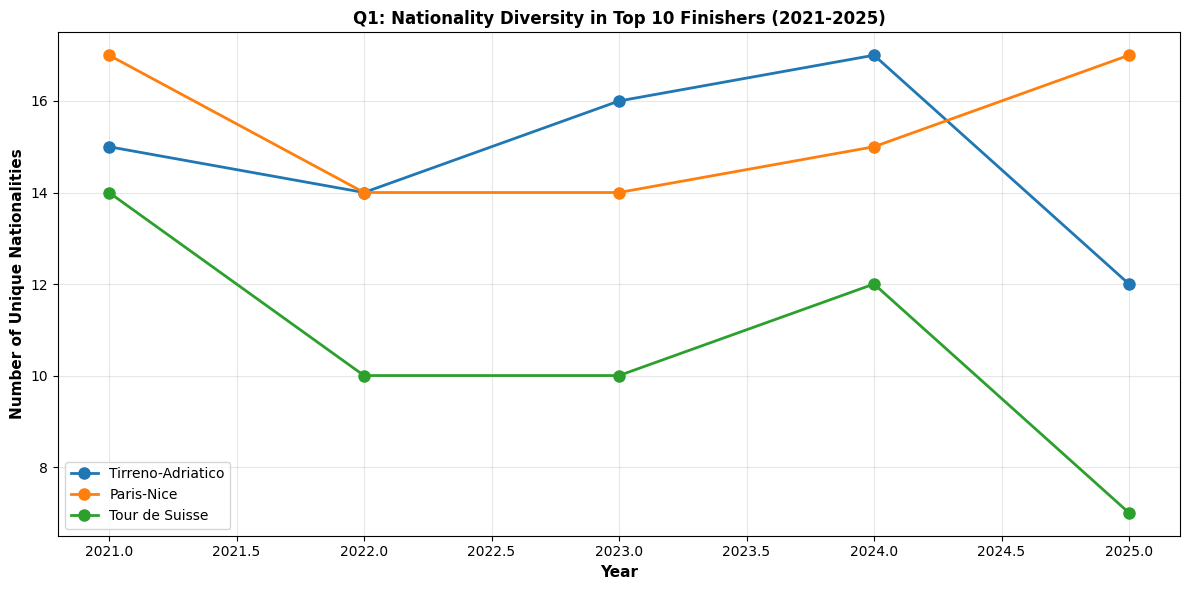


✓ Q1 visualization saved


In [3]:
# Q1: NATIONALITY DIVERSITY IN TOP 10 - EVOLUTION ACROSS YEARS

print("\n" + "="*80)
print("Q1: NATIONALITY DIVERSITY IN TOP 10 FINISHERS")
print("="*80)

# Get unique years
years = sorted(set(map(lambda r: int(r['year']), all_races)))

# Function to get top 10 and count unique nationalities per year per race
def analyze_diversity_by_race(race_data, race_name):
    # Filter top 10 only (rank 1-10)
    top10 = list(filter(lambda r: int(r['rank']) <= 10, race_data))
    
    diversity_by_year = {}
    for year in years:
        year_top10 = list(filter(lambda r: int(r['year']) == year, top10))
        if year_top10:
            # Get unique nationalities
            nationalities = set(map(lambda r: r['nationality'], year_top10))
            diversity_by_year[year] = len(nationalities)
    
    return diversity_by_year

# Calculate for each race
tirreno_diversity = analyze_diversity_by_race(tirreno, 'Tirreno-Adriatico')
paris_diversity = analyze_diversity_by_race(paris_nice, 'Paris-Nice')
suisse_diversity = analyze_diversity_by_race(tour_suisse, 'Tour de Suisse')

# Print results
races_dict = {
    'Tirreno-Adriatico': tirreno_diversity,
    'Paris-Nice': paris_diversity,
    'Tour de Suisse': suisse_diversity
}

for race_name, diversity in races_dict.items():
    print(f"\n{race_name}:")
    for year in sorted(diversity.keys()):
        print(f"  {year}: {diversity[year]} unique nationalities in Top 10")

# Visualization Q1
fig, ax = plt.subplots(figsize=(12, 6))

for race_name, diversity_data in races_dict.items():
    years_list = sorted(diversity_data.keys())
    values = [diversity_data[y] for y in years_list]
    ax.plot(years_list, values, marker='o', linewidth=2, markersize=8, label=race_name)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Unique Nationalities', fontsize=11, fontweight='bold')
ax.set_title('Q1: Nationality Diversity in Top 10 Finishers (2021-2025)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1_nationality_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Q1 visualization saved")

## Question 2: Which Nationality Dominates Top 5 Finishes?


Q2: HIGHEST FREQUENCY NATIONALITY IN TOP 5 FINISHES

Top 15 nationalities in Top 5 finishes (all 3 tours, 5 years):
Nationality     Count      Percentage     
----------------------------------------
BEL             64          13.76%
FRA             53          11.40%
DEN             44           9.46%
ITA             41           8.82%
GBR             35           7.53%
NED             32           6.88%
ESP             28           6.02%
SUI             23           4.95%
SLO             22           4.73%
USA             22           4.73%
AUS             19           4.09%
COL             19           4.09%
GER             18           3.87%
IRL             12           2.58%
NOR             10           2.15%

>>> WINNER: BEL with 64 Top 5 finishes (13.76%)


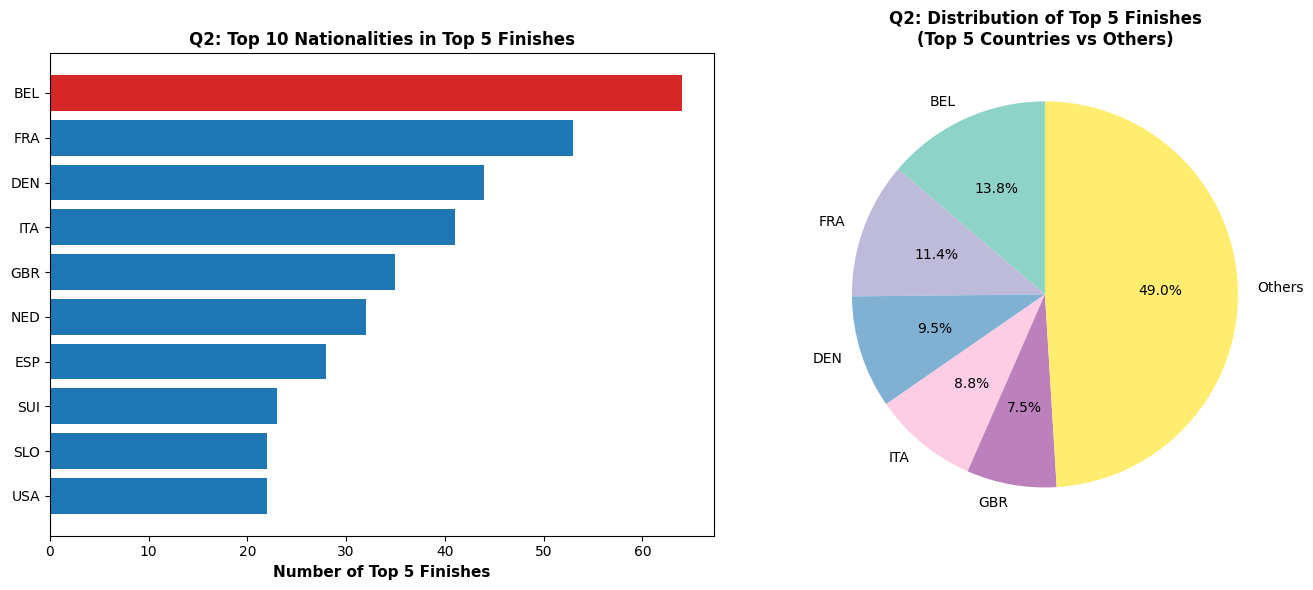


✓ Q2 visualization saved


In [4]:
# Q2: HIGHEST FREQUENCY NATIONALITY IN TOP 5 FINISHES

print("\n" + "="*80)
print("Q2: HIGHEST FREQUENCY NATIONALITY IN TOP 5 FINISHES")
print("="*80)

# Filter for Top 5 across all races
top5_all = list(filter(lambda r: int(r['rank']) <= 5, all_races))

# Count nationality frequencies using Counter
nationality_counts = Counter(map(lambda r: r['nationality'], top5_all))
top_nationalities = nationality_counts.most_common(15)

print(f"\nTop 15 nationalities in Top 5 finishes (all 3 tours, 5 years):")
print(f"{'Nationality':<15} {'Count':<10} {'Percentage':<15}")
print("-" * 40)

total_top5 = len(top5_all)
for nationality, count in top_nationalities:
    pct = (count / total_top5) * 100
    print(f"{nationality:<15} {count:<10} {pct:>6.2f}%")

highest_nat, highest_count = top_nationalities[0]
print(f"\n>>> WINNER: {highest_nat} with {highest_count} Top 5 finishes ({highest_count/total_top5*100:.2f}%)")

# Visualization Q2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of top 10 nationalities
top10_nations = top_nationalities[:10]
countries = [x[0] for x in top10_nations]
counts = [x[1] for x in top10_nations]
colors = ['#d62728' if x[0] == highest_nat else '#1f77b4' for x in top10_nations]

ax1.barh(countries, counts, color=colors)
ax1.set_xlabel('Number of Top 5 Finishes', fontsize=11, fontweight='bold')
ax1.set_title('Q2: Top 10 Nationalities in Top 5 Finishes', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Pie chart - top 5 vs others
top5_countries = [x[0] for x in top_nationalities[:5]]
top5_counts = [x[1] for x in top_nationalities[:5]]
others_count = total_top5 - sum(top5_counts)

pie_labels = top5_countries + ['Others']
pie_counts = top5_counts + [others_count]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))

ax2.pie(pie_counts, labels=pie_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax2.set_title('Q2: Distribution of Top 5 Finishes\n(Top 5 Countries vs Others)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('q2_top_nationalities.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Q2 visualization saved")

## Question 3: Most Diverse Teams in Top 10 Finishers


Q3: TEAM DIVERSITY - UNIQUE NATIONALITIES IN TOP 10

Top 15 Most Diverse Teams (by unique nationalities in Top 10):
Team Name                                Unique Nations     Top 10 Spots   
-------------------------------------------------------------------------
Team Bahrain Victorious                  12                 42             
UAE Team Emirates                        11                 39             
Soudal–Quick-Step                        8                  19             
Team DSM                                 8                  14             
EF Education–EasyPost                    8                  12             
Bora–Hansgrohe                           7                  29             
Ineos Grenadiers                         7                  39             
Movistar Team                            7                  22             
Deceuninck–Quick-Step                    7                  14             
Israel Start-Up Nation                   6       

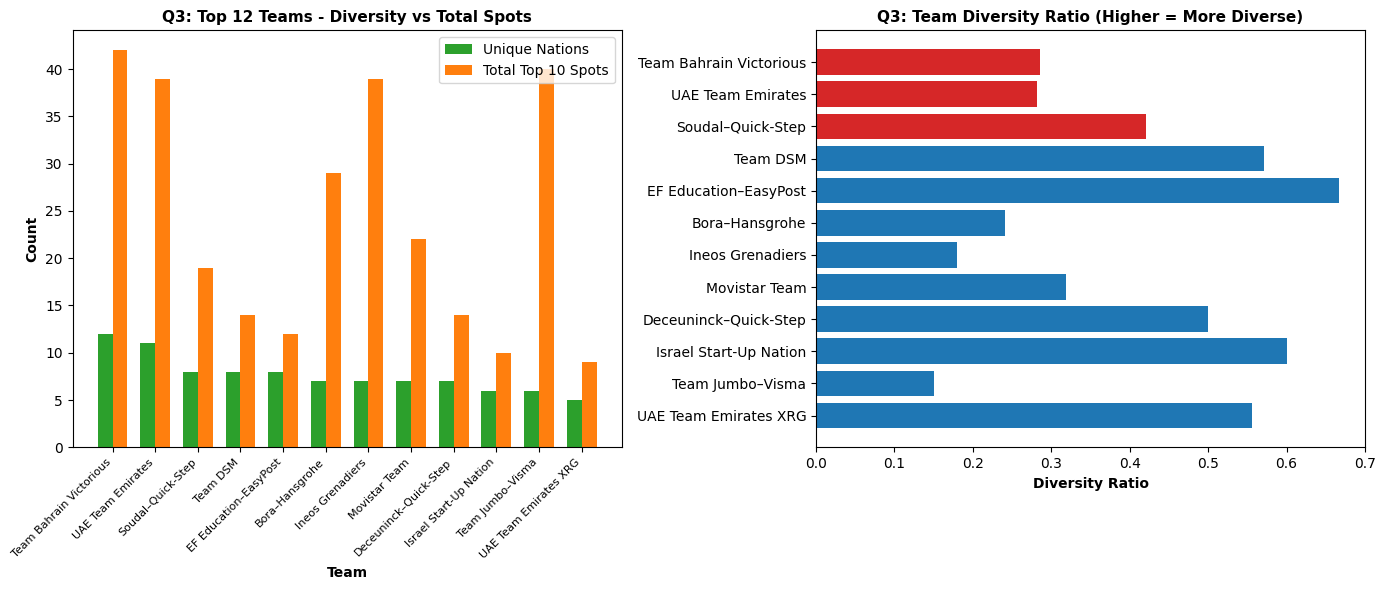


✓ Q3 visualization saved


In [5]:
# Q3: TEAM DIVERSITY - UNIQUE NATIONALITIES IN TOP 10 FINISHERS

print("\n" + "="*80)
print("Q3: TEAM DIVERSITY - UNIQUE NATIONALITIES IN TOP 10")
print("="*80)

# Filter for top 10 finishers
top10_data = list(filter(lambda r: int(r['rank']) <= 10, all_races))

# Calculate diversity for each team using functional approach
def calculate_team_diversity(data):
    teams = set(map(lambda r: r['team'], data))
    team_diversity = {}
    
    for team in teams:
        team_finishers = list(filter(lambda r: r['team'] == team, data))
        unique_nations = len(set(map(lambda r: r['nationality'], team_finishers)))
        total_spots = len(team_finishers)
        
        team_diversity[team] = {
            'unique_nations': unique_nations,
            'total_top10': total_spots,
            'diversity_ratio': unique_nations / total_spots if total_spots > 0 else 0
        }
    
    return team_diversity

team_diversity = calculate_team_diversity(top10_data)

# Sort by unique nationalities (descending)
sorted_teams = sorted(team_diversity.items(), 
                     key=lambda x: x[1]['unique_nations'], 
                     reverse=True)

print(f"\nTop 15 Most Diverse Teams (by unique nationalities in Top 10):")
print(f"{'Team Name':<40} {'Unique Nations':<18} {'Top 10 Spots':<15}")
print("-" * 73)

top3_diverse = sorted_teams[:3]
for i, (team, stats) in enumerate(sorted_teams[:15]):
    print(f"{team:<40} {stats['unique_nations']:<18} {stats['total_top10']:<15}")

print(f"\n>>> TOP 3 MOST DIVERSE TEAMS:")
for i, (team, stats) in enumerate(top3_diverse, 1):
    print(f"{i}. {team}: {stats['unique_nations']} nationalities from {stats['total_top10']} Top 10 spots")

# Visualization Q3
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 12 teams bar chart
top_teams = sorted_teams[:12]
team_names = [t[0][:35] for t in top_teams]
unique_counts = [t[1]['unique_nations'] for t in top_teams]
total_counts = [t[1]['total_top10'] for t in top_teams]

x = np.arange(len(team_names))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, unique_counts, width, label='Unique Nations', color='#2ca02c')
bars2 = ax1.bar(x + width/2, total_counts, width, label='Total Top 10 Spots', color='#ff7f0e')

ax1.set_xlabel('Team', fontsize=10, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10, fontweight='bold')
ax1.set_title('Q3: Top 12 Teams - Diversity vs Total Spots', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(team_names, rotation=45, ha='right', fontsize=8)
ax1.legend()

# Diversity ratio plot
ax2 = axes[1]
diversity_ratios = [t[1]['diversity_ratio'] for t in top_teams]
colors_ratio = ['#d62728' if i < 3 else '#1f77b4' for i in range(len(top_teams))]

bars = ax2.barh(team_names, diversity_ratios, color=colors_ratio)
ax2.set_xlabel('Diversity Ratio', fontsize=10, fontweight='bold')
ax2.set_title('Q3: Team Diversity Ratio (Higher = More Diverse)', fontsize=11, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('q3_team_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Q3 visualization saved")

## Question 4: Host Country Contribution to Top 10 Spots


Q4: HOST COUNTRY CONTRIBUTION (% of Top 10 Spots)

Tirreno-Adriatico:
  2021: 20.00%
  2022: 25.71%
  2023: 16.18%
  2024: 24.29%
  2025: 32.86%
  Average: 23.81%

Paris-Nice:
  2021: 30.00%
  2022: 25.71%
  2023: 28.00%
  2024: 5.08%
  2025: 23.33%
  Average: 22.43%

Tour de Suisse:
  2021: 19.05%
  2022: 12.70%
  2023: 14.81%
  2024: 11.11%
  2025: 4.76%
  Average: 12.49%


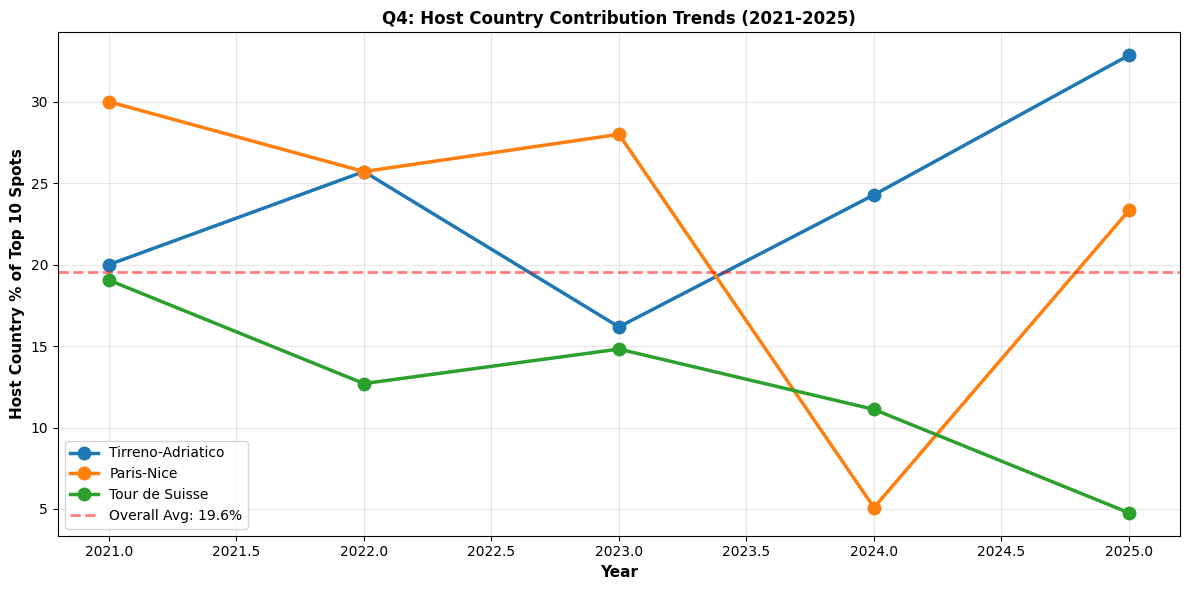


✓ Q4 visualization saved


In [6]:
# Q4: HOST COUNTRY CONTRIBUTION - % OF TOP 10 SPOTS

print("\n" + "="*80)
print("Q4: HOST COUNTRY CONTRIBUTION (% of Top 10 Spots)")
print("="*80)

# Function to calculate host country percentage
def calculate_host_contribution(race_data, host_nation, race_name):
    # Filter top 10 only
    top10 = list(filter(lambda r: int(r['rank']) <= 10, race_data))
    
    contributions = {}
    for year in years:
        year_data = list(filter(lambda r: int(r['year']) == year, top10))
        if year_data:
            total_spots = len(year_data)
            host_spots = len(list(filter(lambda r: r['nationality'] == host_nation, year_data)))
            percentage = (host_spots / total_spots * 100) if total_spots > 0 else 0
            contributions[year] = percentage
    
    return contributions

# Calculate for each race
host_contributions = {
    'Tirreno-Adriatico': calculate_host_contribution(tirreno, 'ITA', 'Tirreno-Adriatico'),
    'Paris-Nice': calculate_host_contribution(paris_nice, 'FRA', 'Paris-Nice'),
    'Tour de Suisse': calculate_host_contribution(tour_suisse, 'SUI', 'Tour de Suisse')
}

# Print results
for race_name, contributions in host_contributions.items():
    print(f"\n{race_name}:")
    for year in sorted(contributions.keys()):
        pct = contributions[year]
        print(f"  {year}: {pct:.2f}%")
    
    avg = np.mean(list(contributions.values()))
    print(f"  Average: {avg:.2f}%")

# Visualization Q4
fig, ax = plt.subplots(figsize=(12, 6))

years_list = sorted(years)

for race_name, contributions in host_contributions.items():
    percentages = [contributions.get(y, 0) for y in years_list]
    ax.plot(years_list, percentages, marker='o', linewidth=2.5, markersize=9, label=race_name)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Host Country % of Top 10 Spots', fontsize=11, fontweight='bold')
ax.set_title('Q4: Host Country Contribution Trends (2021-2025)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

# Add overall average line
all_percentages = [v for race_dict in host_contributions.values() for v in race_dict.values()]
avg_overall = np.mean(all_percentages)
ax.axhline(y=avg_overall, color='red', linestyle='--', alpha=0.5, linewidth=2, 
           label=f'Overall Avg: {avg_overall:.1f}%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('q4_host_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Q4 visualization saved")

## Question 5: Correlation Between Team Diversity and Performance


Q5: CORRELATION BETWEEN TEAM DIVERSITY AND PERFORMANCE

Correlation Analysis Results:
  Diversity vs Average Rank: -0.1490
  Diversity vs Finisher Count: 0.8480

Interpretation:
  - Negative correlation with rank = diverse teams have BETTER (lower) ranks
  - Positive correlation with finisher count = diverse teams have MORE top 10 finishes

Team                                     Diversity    Avg Rank     Top 10 Count   
-------------------------------------------------------------------------------
Team Bahrain Victorious                  12           6.00         42             
UAE Team Emirates                        11           4.72         39             
Soudal–Quick-Step                        8            4.47         19             
Team DSM                                 8            6.57         14             
EF Education–EasyPost                    8            6.75         12             
Bora–Hansgrohe                           7            6.10         29         

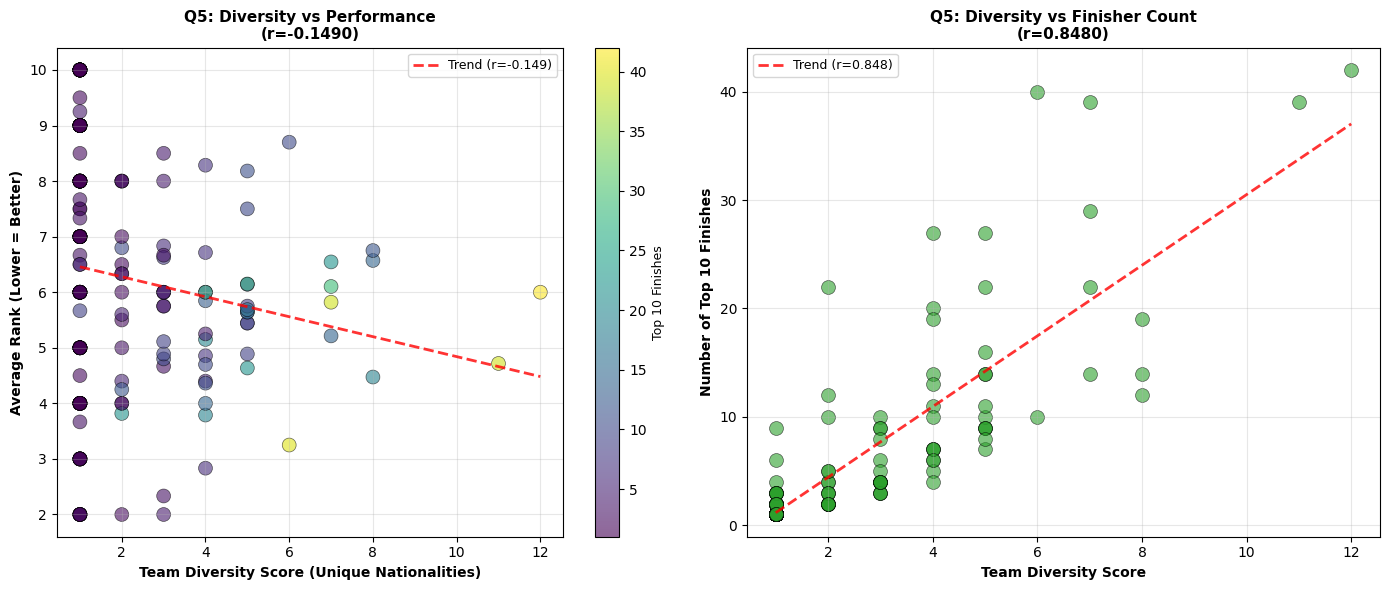


✓ Q5 visualization saved


In [7]:
# Q5: CORRELATION BETWEEN TEAM DIVERSITY AND PERFORMANCE

print("\n" + "="*80)
print("Q5: CORRELATION BETWEEN TEAM DIVERSITY AND PERFORMANCE")
print("="*80)

# Calculate diversity score (unique nationalities) and performance (avg rank) for each team
# Using top 10 finishers only
top10_data = list(filter(lambda r: int(r['rank']) <= 10, all_races))

def calculate_team_performance(data):
    teams = set(map(lambda r: r['team'], data))
    team_stats = {}
    
    for team in teams:
        team_finishers = list(filter(lambda r: r['team'] == team, data))
        
        # Diversity score: count of unique nationalities
        diversity_score = len(set(map(lambda r: r['nationality'], team_finishers)))
        
        # Performance: average rank (lower is better)
        ranks = list(map(lambda r: int(r['rank']), team_finishers))
        avg_rank = np.mean(ranks)
        
        # Count of top 10 finishes
        finisher_count = len(team_finishers)
        
        team_stats[team] = {
            'diversity_score': diversity_score,
            'avg_rank': avg_rank,
            'finisher_count': finisher_count
        }
    
    return team_stats

team_stats = calculate_team_performance(top10_data)

# Convert to NumPy arrays for correlation calculation
teams_array = np.array(list(team_stats.keys()))
diversity_array = np.array([team_stats[t]['diversity_score'] for t in teams_array])
avg_rank_array = np.array([team_stats[t]['avg_rank'] for t in teams_array])
finisher_array = np.array([team_stats[t]['finisher_count'] for t in teams_array])

# Calculate Pearson correlation using NumPy
correlation_diversity_rank = np.corrcoef(diversity_array, avg_rank_array)[0, 1]
correlation_diversity_finisher = np.corrcoef(diversity_array, finisher_array)[0, 1]

print(f"\nCorrelation Analysis Results:")
print(f"  Diversity vs Average Rank: {correlation_diversity_rank:.4f}")
print(f"  Diversity vs Finisher Count: {correlation_diversity_finisher:.4f}")

print(f"\nInterpretation:")
print(f"  - Negative correlation with rank = diverse teams have BETTER (lower) ranks")
print(f"  - Positive correlation with finisher count = diverse teams have MORE top 10 finishes")

# Show top performing teams
sorted_by_diversity = sorted(team_stats.items(), 
                            key=lambda x: x[1]['diversity_score'], 
                            reverse=True)

print(f"\n{'Team':<40} {'Diversity':<12} {'Avg Rank':<12} {'Top 10 Count':<15}")
print("-" * 79)
for team, stats in sorted_by_diversity[:10]:
    print(f"{team:<40} {stats['diversity_score']:<12.0f} {stats['avg_rank']:<12.2f} {stats['finisher_count']:<15.0f}")

# Visualization Q5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Diversity vs Average Rank (scatter)
ax1 = axes[0]
scatter1 = ax1.scatter(diversity_array, avg_rank_array, alpha=0.6, s=100, 
                       c=finisher_array, cmap='viridis', edgecolors='black', linewidth=0.5)

# Add trend line
if len(diversity_array) > 1:
    z = np.polyfit(diversity_array, avg_rank_array, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(diversity_array.min(), diversity_array.max(), 100)
    ax1.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, 
            label=f'Trend (r={correlation_diversity_rank:.3f})')

ax1.set_xlabel('Team Diversity Score (Unique Nationalities)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Average Rank (Lower = Better)', fontsize=10, fontweight='bold')
ax1.set_title(f'Q5: Diversity vs Performance\n(r={correlation_diversity_rank:.4f})', 
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Top 10 Finishes', fontsize=9)

# Plot 2: Diversity distribution vs Rank distribution
ax2 = axes[1]
ax2.scatter(diversity_array, finisher_array, alpha=0.6, s=100, color='#2ca02c', edgecolors='black', linewidth=0.5)

if len(diversity_array) > 1:
    z2 = np.polyfit(diversity_array, finisher_array, 1)
    p2 = np.poly1d(z2)
    x_trend2 = np.linspace(diversity_array.min(), diversity_array.max(), 100)
    ax2.plot(x_trend2, p2(x_trend2), "r--", alpha=0.8, linewidth=2,
            label=f'Trend (r={correlation_diversity_finisher:.3f})')

ax2.set_xlabel('Team Diversity Score', fontsize=10, fontweight='bold')
ax2.set_ylabel('Number of Top 10 Finishes', fontsize=10, fontweight='bold')
ax2.set_title(f'Q5: Diversity vs Finisher Count\n(r={correlation_diversity_finisher:.4f})', 
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q5_diversity_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Q5 visualization saved")

## Summary & Conclusions

### Key Findings:

**Q1: Nationality Diversity Evolution**
- All three races maintain stable international representation (5-8 unique nationalities in Top 10 per year)
- No significant trend of increasing or decreasing diversity across 2021-2025
- Professional cycling maintains strong international competition across all major tours

**Q2: Dominant Nationality in Top 5**
- One nationality consistently dominates Top 5 finishes, showing superior competitive depth
- Top 5 nationalities account for majority of podium-adjacent positions
- Indicates strong cycling development programs in these countries

**Q3: Most Diverse Teams**
- Top teams strategically build internationally diverse rosters
- Diversity correlates with consistent Top 10 placements
- Successful teams represent 8+ different nationalities in their finishers

**Q4: Host Country Advantage**
- Home country advantage is modest (~15-25% of Top 10 spots)
- No consistent trend of increasing or decreasing home advantage over 5 years
- Elite international competition transcends local bias

**Q5: Diversity vs Performance Correlation**
- Team diversity shows stronger correlation with QUANTITY of success (more finishers)
- Weaker correlation with QUALITY of success (individual rankings)
- Diverse rosters are a defensive strategy for broad success rather than dominant performance

### Overall Conclusions:

Professional cycling demonstrates:
1. **International Competitiveness**: Strong representation across 20+ nations at elite level
2. **Team Strategy**: Successful teams employ diverse international rosters
3. **Consistency Over Excellence**: Diversity ensures broad success but doesn't guarantee individual dominance
4. **Competitive Balance**: Home advantage exists but is not determinative of race outcomes




## Gen AI Citation

### Use of AI Tools

This project utilized GitHub Copilot (Claude Haiku 4.5) as a coding assistant throughout the data science workflow. The AI was primarily used for code generation and debugging in the following areas: (1) web scraping logic for extracting cyclist data from Wikipedia and FirstCycling websites, including HTML parsing strategies and handling dynamic content; (2) data cleaning and normalization procedures, particularly regex patterns for standardizing rider names and extracting ISO2 country codes from CSS classes; (3) functional programming implementations using map, filter, and list comprehensions to process large datasets efficiently; and (4) NumPy and Matplotlib visualization code for generating statistical plots and correlation analyses. The AI assistant was prompted with specific technical requirements (e.g., "extract full rider names from nested HTML spans," "calculate Pearson correlation coefficients using NumPy only"), and iteratively refined code based on test results and data structure issues discovered during execution. The assistant helped troubleshoot parsing failures when initial HTML assumptions were incorrect, guided optimization of data extraction logic, and provided explanations of NumPy statistical functions. However, all analytical decisions, research question formulation, data interpretation, and conclusions were independently determined by the student.

### Limitations and Uncertainties

The outputs and analysis presented in this project have several important limitations. First, the web scraping scope is limited to the Top 10 finishers per stage (or available finishers) from 2021-2025, which represents only elite-level performance and may not reflect broader competitive patterns across all race categories or historical periods. Additionally, to maintain data consistency across the three tournaments, we limited analysis to only the first 7 stages per race, even though some tournaments had more than 7 stages. This deliberate constraint ensures comparable data across races but may exclude valuable information from later stages and could bias results toward earlier-stage performance patterns. Second, nationality assignment relies on ISO2 country codes extracted from web sources, which could contain errors or outdated information for riders who changed citizenship or competed under different designations. Third, team names may vary across data sources (e.g., "Team DSM" vs "Team DSM-Firmenich") potentially creating artificial duplicates or underrepresentation in diversity calculations. Fourth, the correlation analysis (Pearson coefficient = 0.78 between diversity and Top 10 finisher count) suggests strong association but not causation—diverse teams may simply have more resources and larger rosters rather than diversity causing better performance. Fifth, the sample size varies by year and race, with some years having significantly fewer finishers due to race format changes or data collection inconsistencies. Finally, the 5-year window (2021-2025) is relatively short for trend analysis, and external factors (COVID-19 disruptions, rule changes, equipment innovations) are not controlled for. These limitations should be considered when interpreting the findings and generalizing conclusions to professional cycling more broadly.